In [6]:
#데이터 셋 다운로드
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler #스케일러 추가
from sklearn.decomposition import PCA #차원 축소용
import matplotlib.pyplot as plt

wine = datasets.load_wine()
print(wine)
print(wine.target_names)

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
 

In [7]:
#훈련 데이터 및 테스트 데이터 분리
X = wine.data
y = wine.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=109)
scaler = StandardScaler()                         #데이터 스케일링
X_train_scaled = scaler.fit_transform(X_train)    #훈련 데이터로 스케일링 기준 학습 및 변환
X_test_scaled = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(124, 13)
(54, 13)


In [11]:
#학습
knn = KNeighborsClassifier(n_neighbors=5) #6에서 5으로 변경
knn.fit(X_train_scaled, y_train) #X_train -> X_train_scaled 변경

KNeighborsClassifier()

In [15]:
#정확도
y_pred = knn.predict(X_test_scaled)

score = metrics.accuracy_score(y_test, y_pred)
print(f"{score: .4f}")

 0.9444


In [33]:
#예측
classes = wine.target_names

x_new = [[5, 2, 3, 5, 1, 0.6, 23, 54, 22, 14, 7, 2, 500],
         [14.23, 0.05, 127, 1024, 15, 8.73, 1.09, 88, 0.12, 155, 13.27, 9, 3]]

x_new_scaled = scaler.transform(x_new)
y_predict = knn.predict(x_new_scaled)

print(classes[y_predict[0]])
print(classes[y_predict[1]])


class_1
class_2


----------------------------------------------

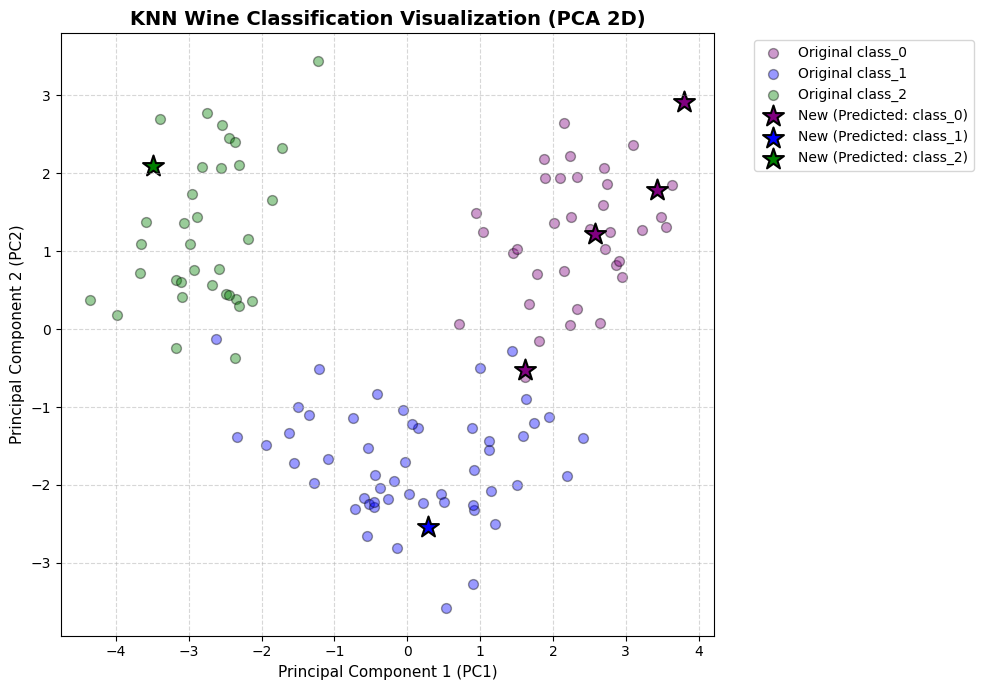

In [35]:
#새로운 여러개의 데이터 준비 및 시각화 하기

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

x_new = [
    [14.23, 1.71, 2.43, 15.6, 127, 2.80, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065],
    [12.37, 1.17, 1.92, 19.6,  78, 2.11, 2.00, 0.27, 1.04, 4.68, 1.12, 3.48,  510],
    [13.16, 2.36, 2.67, 18.6, 101, 2.80, 3.24, 0.30, 2.81, 5.68, 1.03, 3.17, 1185],
    [14.37, 1.95, 2.50, 16.8, 113, 3.85, 3.49, 0.24, 2.18, 7.80, 0.86, 3.45, 1480],
    [13.71, 5.65, 2.45, 20.5,  95, 1.68, 0.61, 0.52, 1.06, 7.70, 0.64, 1.74,  740],
    [12.85, 1.60, 2.52, 17.8,  95, 2.48, 2.37, 0.26, 1.46, 3.93, 1.09, 3.63,  870]
]

x_new_scaled = scaler.transform(x_new)
y_predict = knn.predict(x_new_scaled)

# 시각화를 위한 차원 축소
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
x_new_pca = pca.transform(x_new_scaled)

# 그래프 그리기
plt.figure(figsize=(10, 7))

# 데이터 색상
colors = ['purple', 'blue', 'green']

# 기존 학습 데이터
for i, class_name in enumerate(wine.target_names):
    plt.scatter(X_train_pca[y_train == i, 0], X_train_pca[y_train == i, 1],
                alpha=0.4, label=f'Original {class_name}', c=colors[i], edgecolors='k', s=50)

# 새로운 데이터 예측 결과
legend_added = set()
for i in range(len(x_new)):
    pred_class = y_predict[i]
    class_label = wine.target_names[pred_class]
    lbl = f'New (Predicted: {class_label})'

    if lbl not in legend_added:
        plt.scatter(x_new_pca[i, 0], x_new_pca[i, 1],
                    s=250, marker='*', c=colors[pred_class], edgecolors='black', linewidth=1.5, label=lbl)
        legend_added.add(lbl)
    else:
        plt.scatter(x_new_pca[i, 0], x_new_pca[i, 1],
                    s=250, marker='*', c=colors[pred_class], edgecolors='black', linewidth=1.5)

# 그래프 설정
plt.title("KNN Wine Classification Visualization (PCA 2D)", fontsize=14, fontweight='bold')
plt.xlabel("Principal Component 1 (PC1)", fontsize=11)
plt.ylabel("Principal Component 2 (PC2)", fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()